# Spectroscopic Redshift Verification

Independent check of the deflector and source redshifts for AGEL0206 by
fitting Gaussian profiles to known absorption and emission lines in the
KCWI IFU spectrum.

Inspired by Keerthi Vasan's Keck-AGELDR2 pipeline (ESI + NIRES).

**Expected redshifts:**
- Deflector: z = 0.675 (absorption: Ca H+K, G-band, H-delta, H-gamma)
- Source: z = 1.302 (emission: [OII] 3727 → ~8580 Å observed)

**KCWI wavelength coverage:** 5625–8941 Å (observed)

## 1. Load IFU data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
import importlib
sys.path.insert(0, '..')
import scripts.redshift_verify as rv
importlib.reload(rv)
from scripts.redshift_verify import (
    verify_redshift, plot_line_fits, plot_spectrum_with_lines,
    fit_cahk_doublet, fit_oii_doublet, ABSORPTION_LINES, EMISSION_LINES
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)
plt.rc('axes', linewidth=1.5, labelsize=16)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')

In [2]:
# Load IFU cube
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

# Build wavelength array (Angstroms, vacuum)
crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
pix = np.arange(npix)
lam = crval + cdelt * (pix + 1 - crpix)

# Vacuum to air conversion
def vac_to_air(lam_vac):
    s = 1e4 / lam_vac
    n = 1 + 0.0000834254 + 0.02406147 / (130 - s**2) + 0.00015998 / (38.9 - s**2)
    return lam_vac / n

lam_air = vac_to_air(lam)

# Integrated spectra
deflector_flux = np.average(cube[:, 45:64, 45:55], axis=(1, 2))
noise_flux = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

print(f'Wavelength range: {lam_air[0]:.1f} - {lam_air[-1]:.1f} Angstroms (air)')
print(f'Deflector spectrum: {deflector_flux.shape}')

Wavelength range: 5623.4 - 8938.5 Angstroms (air)
Deflector spectrum: (3317,)


## 2. Full spectrum with expected line positions

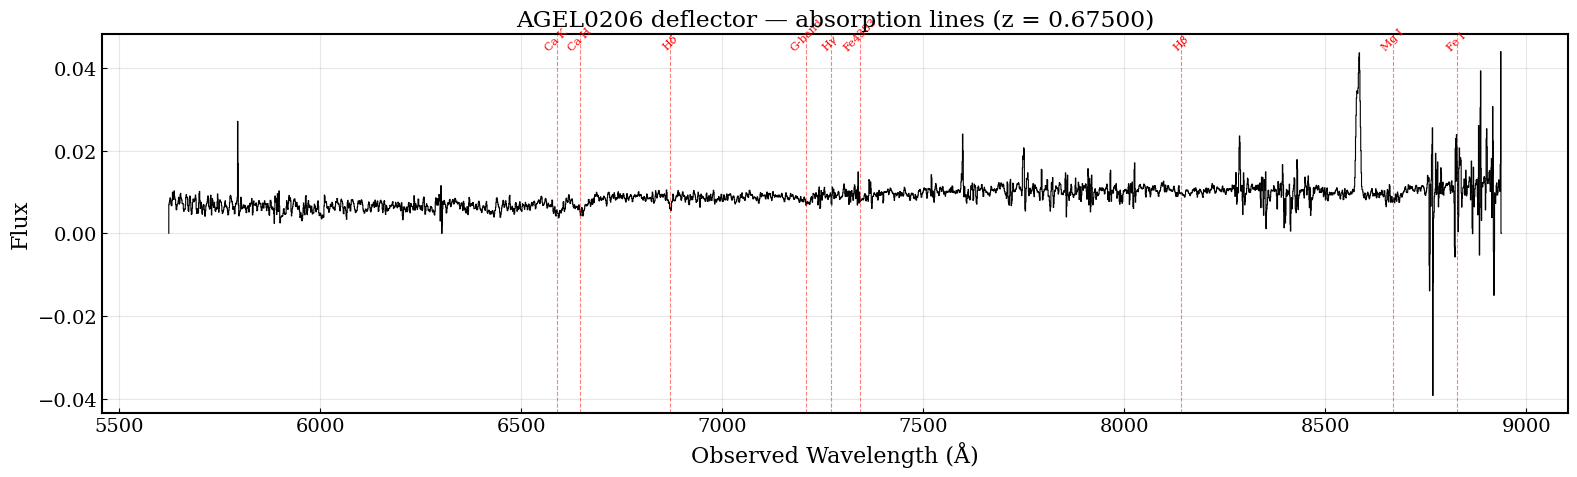

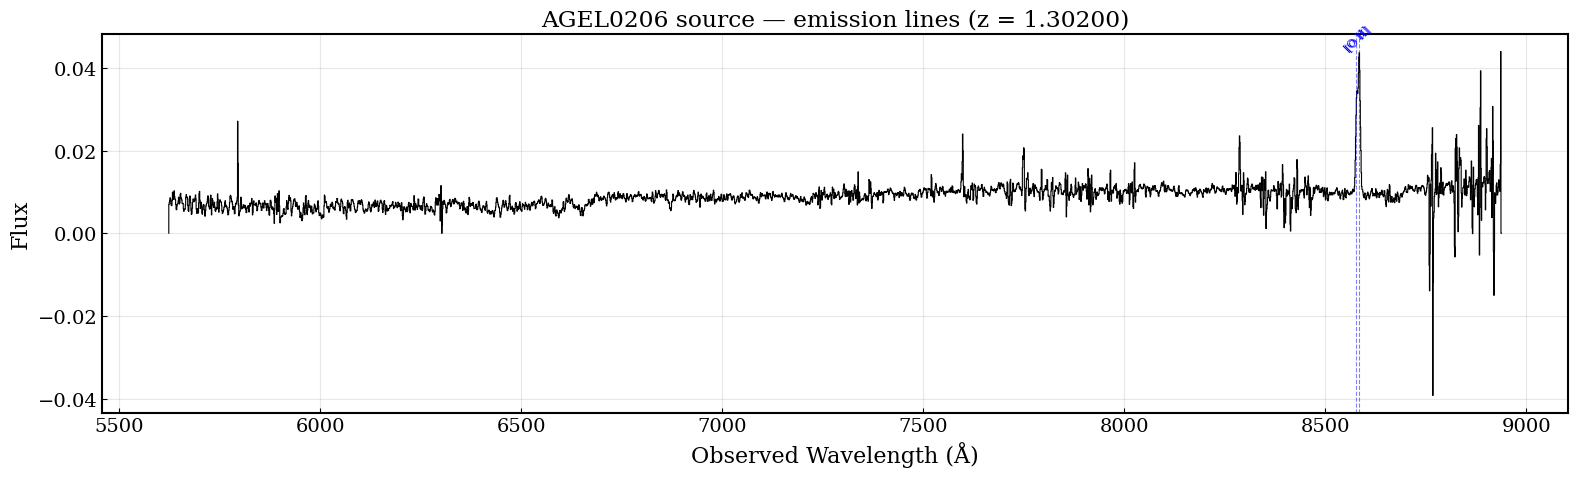

In [3]:
# Plot spectrum with deflector absorption lines at z=0.675
z_defl_guess = 0.675
fig = plot_spectrum_with_lines(lam_air, deflector_flux, z_defl_guess,
                                emission=False,
                                title='AGEL0206 deflector — absorption lines')
plt.show()

# Plot spectrum with source emission lines at z=1.302
z_src_guess = 1.302
fig = plot_spectrum_with_lines(lam_air, deflector_flux, z_src_guess,
                                emission=True,
                                title='AGEL0206 source — emission lines')
plt.show()

## 3. Deflector redshift: fit absorption lines

In [4]:
# Curated line lists for the deflector at z~0.675
# Absorption: stellar features we trust as real anchors
DEFLECTOR_ABS_LINES = {
    'Ca K':    {'lambda': 3933.66, 'label': 'Ca K'},
    'Ca H':    {'lambda': 3968.47, 'label': 'Ca H'},
    'H-delta': {'lambda': 4101.74, 'label': r'H$\delta$'},
    'G-band':  {'lambda': 4304.40, 'label': 'G-band'},
    'H-beta':  {'lambda': 4861.33, 'label': r'H$\beta$ (tentative)'},
}

# Emission: lines the deflector itself may produce (star-forming spiral)
DEFLECTOR_EM_LINES = {
    '[O II] 3726': {'lambda': 3726.03, 'label': '[O II] 3726'},
    '[O II] 3729': {'lambda': 3728.82, 'label': '[O II] 3729'},
    'H-beta em':   {'lambda': 4861.33, 'label': r'H$\beta$ em'},
    '[O III] 4959': {'lambda': 4958.91, 'label': '[O III] 4959'},
    '[O III] 5007': {'lambda': 5006.84, 'label': '[O III] 5007'},
}

# --- Fit absorption lines ---
defl_abs_result = verify_redshift(
    lam_air, deflector_flux, z_guess=z_defl_guess,
    noise=noise_flux, emission=False, window_angstrom=30.0,
    line_dict=DEFLECTOR_ABS_LINES
)

print("ABSORPTION LINES (red cube):")
print(f"{'Line':<20} {'z_fit':>10} {'z_err':>10} {'center (Å)':>12} {'sigma (Å)':>10}")
print('-' * 65)
for name, r in defl_abs_result['per_line'].items():
    if r['success']:
        print(f"{name:<20} {r['z_fit']:10.5f} {r['z_err']:10.5f} "
              f"{r.get('center', np.nan):12.2f} {r.get('sigma', np.nan):10.2f}")
    else:
        print(f"{name:<20} {'FAILED':>10} {r.get('message', ''):>30}")
print(f"Weighted z (abs) = {defl_abs_result['z_weighted']:.5f} ± {defl_abs_result['z_weighted_err']:.5f}")

# --- Fit emission lines ---
defl_em_result = verify_redshift(
    lam_air, deflector_flux, z_guess=z_defl_guess,
    noise=noise_flux, emission=True, window_angstrom=30.0,
    line_dict=DEFLECTOR_EM_LINES
)

print(f"\nEMISSION LINES (red cube):")
print(f"{'Line':<20} {'z_fit':>10} {'z_err':>10} {'center (Å)':>12} {'sigma (Å)':>10}")
print('-' * 65)
for name, r in defl_em_result['per_line'].items():
    if r['success']:
        print(f"{name:<20} {r['z_fit']:10.5f} {r['z_err']:10.5f} "
              f"{r.get('center', np.nan):12.2f} {r.get('sigma', np.nan):10.2f}")
    else:
        print(f"{name:<20} {'FAILED':>10} {r.get('message', ''):>30}")
if defl_em_result['n_lines_fit'] > 0:
    print(f"Weighted z (em) = {defl_em_result['z_weighted']:.5f} ± {defl_em_result['z_weighted_err']:.5f}")
else:
    print("No deflector emission lines detected in red cube")

# --- Combined summary ---
# Keep defl_result as the absorption result for downstream cells
defl_result = defl_abs_result

print(f"\n--- Red cube deflector summary ---")
print(f"  Absorption z = {defl_abs_result['z_weighted']:.5f} ± {defl_abs_result['z_weighted_err']:.5f} ({defl_abs_result['n_lines_fit']} lines)")
if defl_em_result['n_lines_fit'] > 0:
    print(f"  Emission z   = {defl_em_result['z_weighted']:.5f} ± {defl_em_result['z_weighted_err']:.5f} ({defl_em_result['n_lines_fit']} lines)")
print(f"  ppxf z       = 0.67511")

ABSORPTION LINES (red cube):
Line                      z_fit      z_err   center (Å)  sigma (Å)
-----------------------------------------------------------------
Ca K                    0.67574    0.00096      6591.79      11.48
Ca H                    0.67561    0.00097      6649.61      16.56
H-delta                 0.67534    0.00058      6871.80       3.26
G-band                  0.67487    0.00160      7209.31      11.30
H-beta                  0.67635    0.00082      8149.30       2.78
Ca H+K doublet          0.67567    0.00069          nan      11.15
Weighted z (abs) = 0.67564 ± 0.00033

EMISSION LINES (red cube):
Line                      z_fit      z_err   center (Å)  sigma (Å)
-----------------------------------------------------------------
[O II] 3726             0.67530    0.00413      6242.23      20.00
[O II] 3729             0.67474    0.00034      6244.80       0.70
H-beta em               0.67372    0.00028      8136.49       0.66
[O III] 4959            0.67538    0.

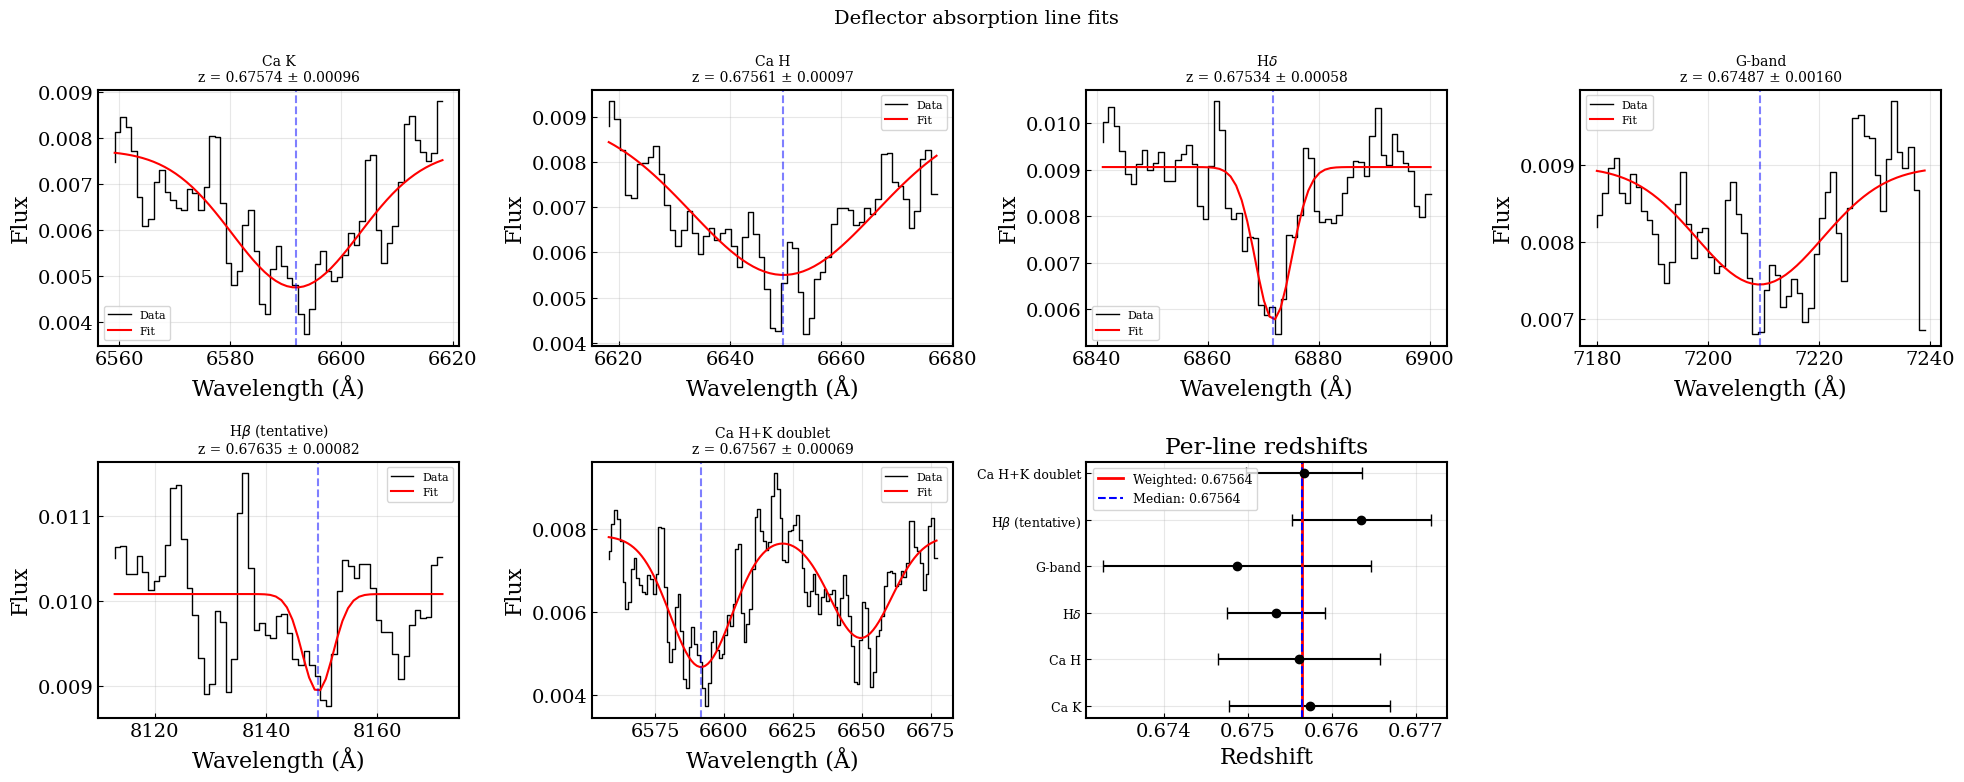

In [5]:
# Plot individual line fits
fig = plot_line_fits(defl_result, title='Deflector absorption line fits')
plt.show()

## 4. Ca H+K doublet fit (tied velocity width)

Ca H+K doublet fit:
  z(Ca K) = 0.67571 ± 0.00089
  z(Ca H) = 0.67562 ± 0.00107
  z(avg)  = 0.67567 ± 0.00069
  sigma   = 11.15 Å


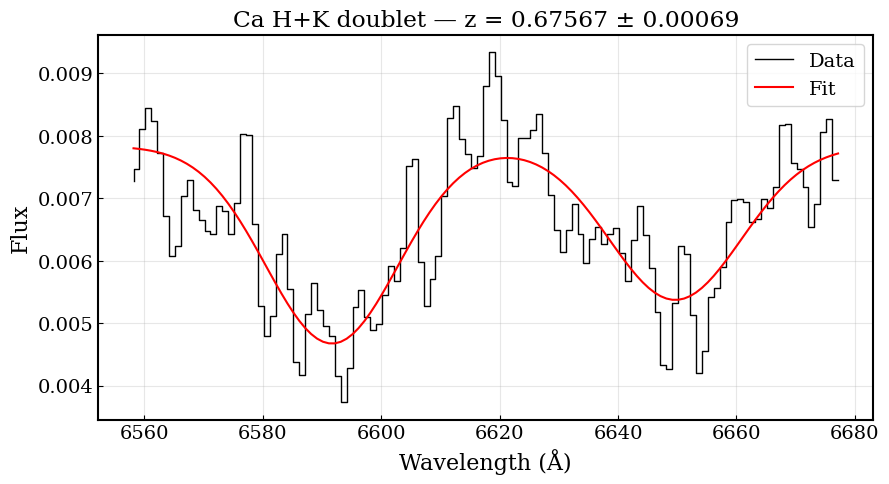

In [6]:
# Fit Ca H+K doublet with shared width
cahk = fit_cahk_doublet(lam_air, deflector_flux, z_guess=z_defl_guess,
                         window_angstrom=60.0, noise=noise_flux)

if cahk['success']:
    print(f"Ca H+K doublet fit:")
    print(f"  z(Ca K) = {cahk['z_cak']:.5f} ± {cahk['z_cak_err']:.5f}")
    print(f"  z(Ca H) = {cahk['z_cah']:.5f} ± {cahk['z_cah_err']:.5f}")
    print(f"  z(avg)  = {cahk['z_fit']:.5f} ± {cahk['z_err']:.5f}")
    print(f"  sigma   = {cahk['sigma']:.2f} Å")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(cahk['wl_window'], cahk['flux_window'], 'k', lw=1, label='Data')
    ax.plot(cahk['wl_window'], cahk['model'], 'r', lw=1.5, label='Fit')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux')
    ax.set_title(f"Ca H+K doublet — z = {cahk['z_fit']:.5f} ± {cahk['z_err']:.5f}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print(f"Ca H+K fit failed: {cahk.get('message', 'unknown')}")

## 5. Source redshift: look for [OII] emission

[OII] doublet fit (integrated spectrum):
  z = 1.30251 ± 0.00004
  3726 center: 8579.2 Å
  3729 center: 8585.6 Å
  Flux ratio (3726/3729): 0.71
  sigma: 2.55 Å


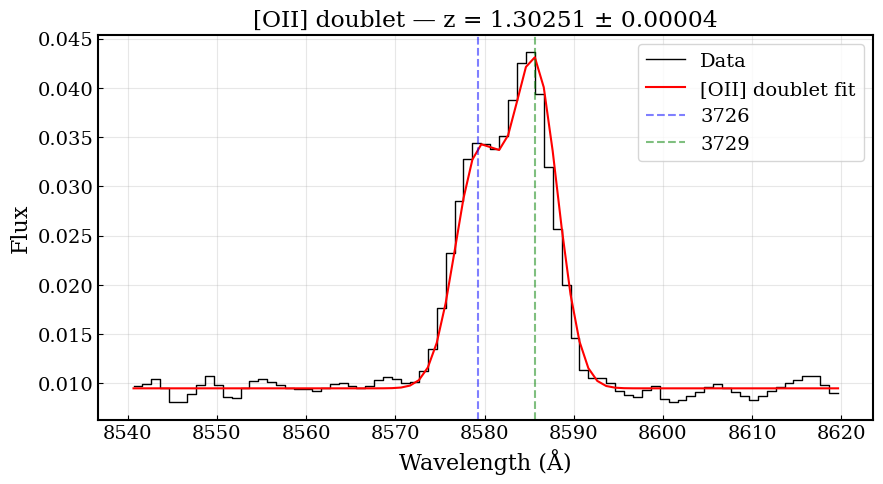


All emission line search (z_guess=1.302):
Line                      z_fit      z_err
---------------------------------------------
[O II] 3726             1.30357    0.00005
[O II] 3729             1.30185    0.00005
[OII] doublet           1.30251    0.00004

Weighted z = 1.30263 ± 0.00003


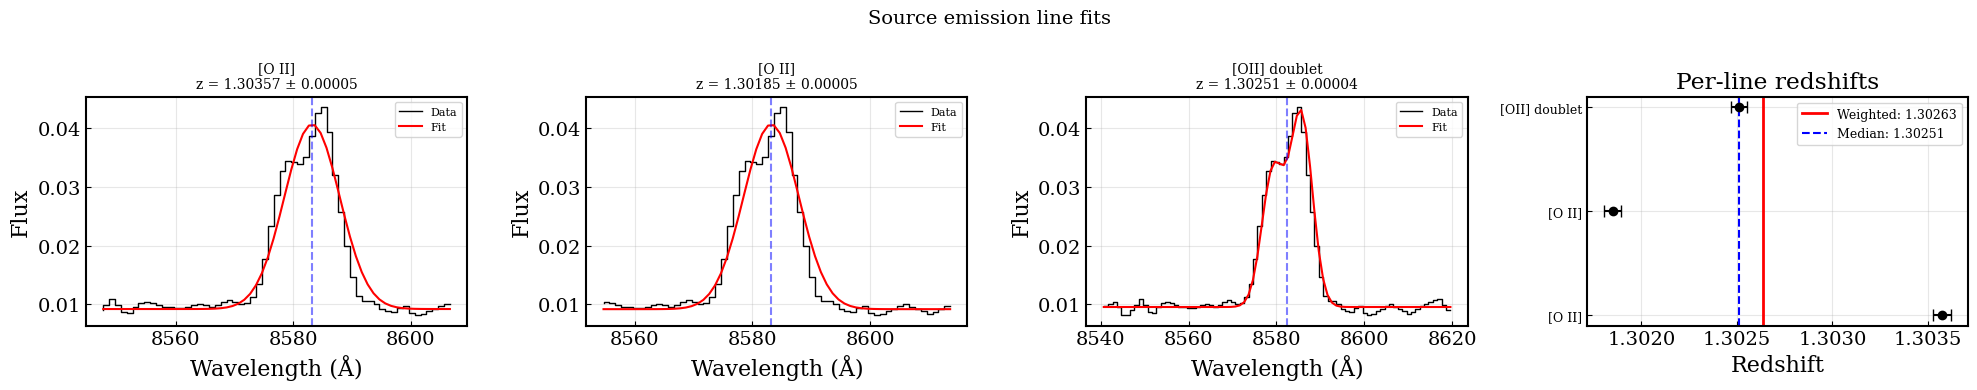

In [7]:
# Source [OII] 3726/3729 doublet at z=1.302 → ~8580 Å observed
# Near the red edge of KCWI coverage (~8941 Å)

# --- Try [OII] doublet fit on integrated spectrum ---
oii_int = fit_oii_doublet(lam_air, deflector_flux, z_guess=z_src_guess,
                           window_angstrom=40.0, noise=noise_flux)

if oii_int['success']:
    print(f"[OII] doublet fit (integrated spectrum):")
    print(f"  z = {oii_int['z_fit']:.5f} ± {oii_int['z_err']:.5f}")
    print(f"  3726 center: {oii_int['center_3726']:.1f} Å")
    print(f"  3729 center: {oii_int['center_3729']:.1f} Å")
    print(f"  Flux ratio (3726/3729): {oii_int['ratio']:.2f}")
    print(f"  sigma: {oii_int['sigma']:.2f} Å")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(oii_int['wl_window'], oii_int['flux_window'], 'k', lw=1, label='Data')
    ax.plot(oii_int['wl_window'], oii_int['model'], 'r', lw=1.5, label='[OII] doublet fit')
    ax.axvline(oii_int['center_3726'], color='blue', ls='--', alpha=0.5, label='3726')
    ax.axvline(oii_int['center_3729'], color='green', ls='--', alpha=0.5, label='3729')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux')
    ax.set_title(f"[OII] doublet — z = {oii_int['z_fit']:.5f} ± {oii_int['z_err']:.5f}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print(f"[OII] doublet fit failed on integrated spectrum: {oii_int.get('message', '')}")
    print("Will try arc spaxels in the next section.")

# --- Also run verify_redshift for all emission lines ---
src_result = verify_redshift(
    lam_air, deflector_flux, z_guess=z_src_guess,
    noise=noise_flux, emission=True, window_angstrom=30.0
)

print(f"\nAll emission line search (z_guess={z_src_guess}):")
print(f"{'Line':<20} {'z_fit':>10} {'z_err':>10}")
print('-' * 45)
for name, r in src_result['per_line'].items():
    if r['success']:
        print(f"{name:<20} {r['z_fit']:10.5f} {r['z_err']:10.5f}")
    else:
        print(f"{name:<20} {'FAILED':>10}")

if src_result['n_lines_fit'] > 0:
    print(f"\nWeighted z = {src_result['z_weighted']:.5f} ± {src_result['z_weighted_err']:.5f}")
    fig = plot_line_fits(src_result, title='Source emission line fits')
    plt.show()

## 6. Source emission from arc spaxels

If the source [OII] emission is diluted in the integrated spectrum,
extract from spaxels dominated by the lensed arc.

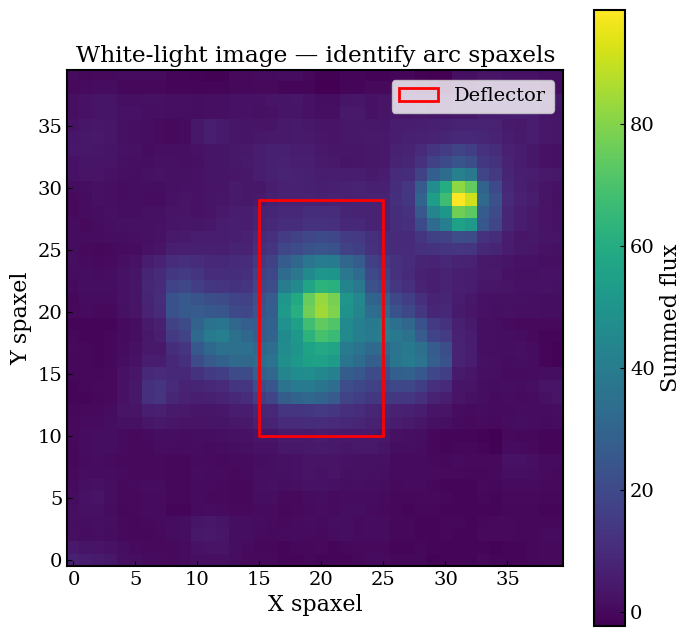

Adjust the arc spaxel region below based on the white-light image.
Look for extended emission offset from the deflector center.


In [8]:
# White-light image to identify arc spaxels
fig, ax = plt.subplots(figsize=(8, 8))
whitelight = np.sum(cube[:, 35:75, 30:70], axis=0)
im = ax.imshow(whitelight, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label='Summed flux')
ax.set_title('White-light image — identify arc spaxels')
ax.set_xlabel('X spaxel')
ax.set_ylabel('Y spaxel')

# Mark the deflector region for reference
from matplotlib.patches import Rectangle
defl_rect = Rectangle((45-30, 45-35), 10, 19, linewidth=2,
                       edgecolor='red', facecolor='none', label='Deflector')
ax.add_patch(defl_rect)
ax.legend()
plt.show()

print("Adjust the arc spaxel region below based on the white-light image.")
print("Look for extended emission offset from the deflector center.")

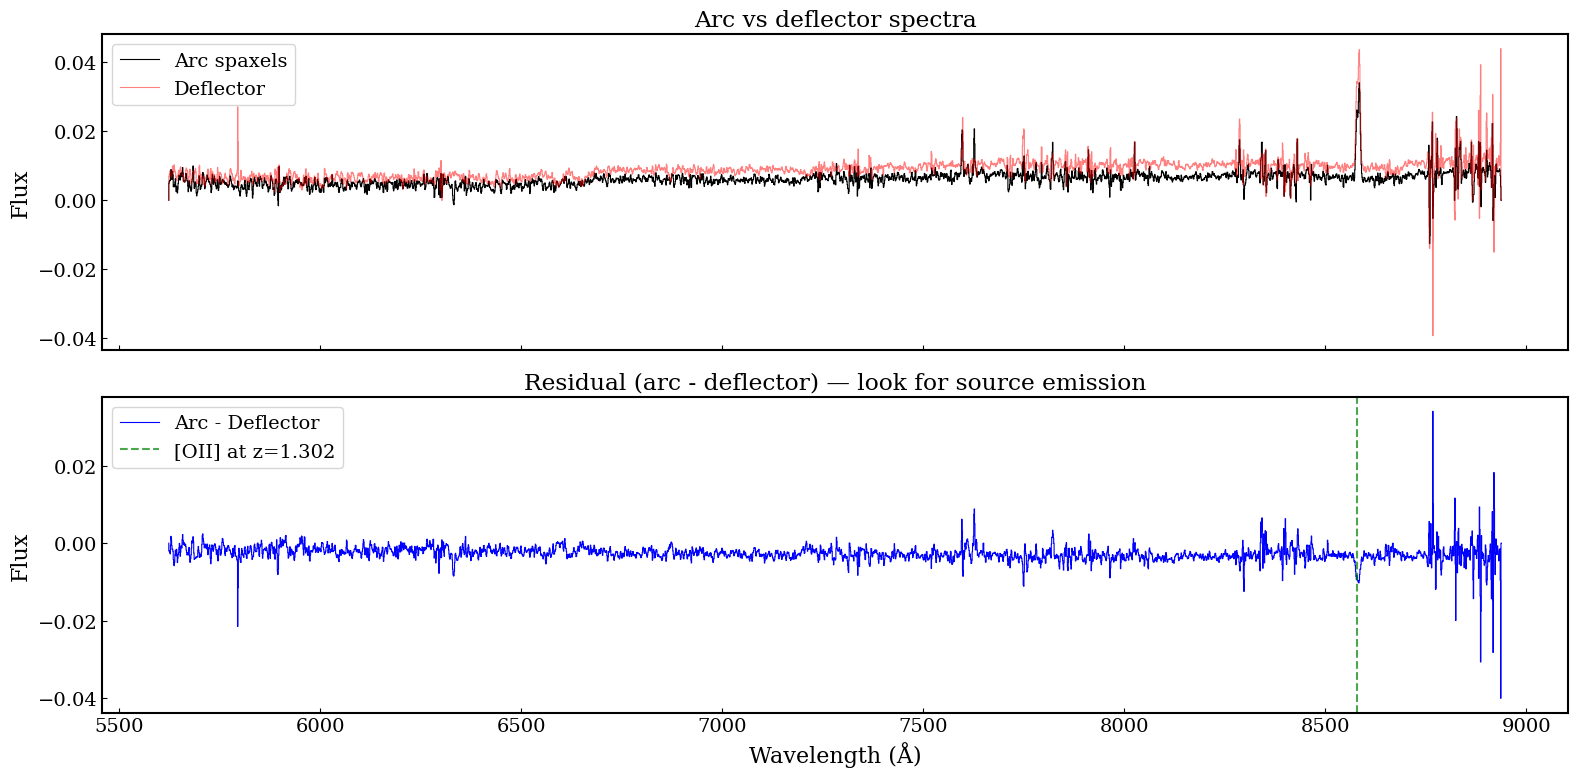

[OII] doublet fit (arc - deflector):
  z = 1.29455 ± 0.09240
  3726 center: 8549.6 Å
  3729 center: 8556.0 Å
  Flux ratio (3726/3729): 0.48
  sigma: 9.47 Å


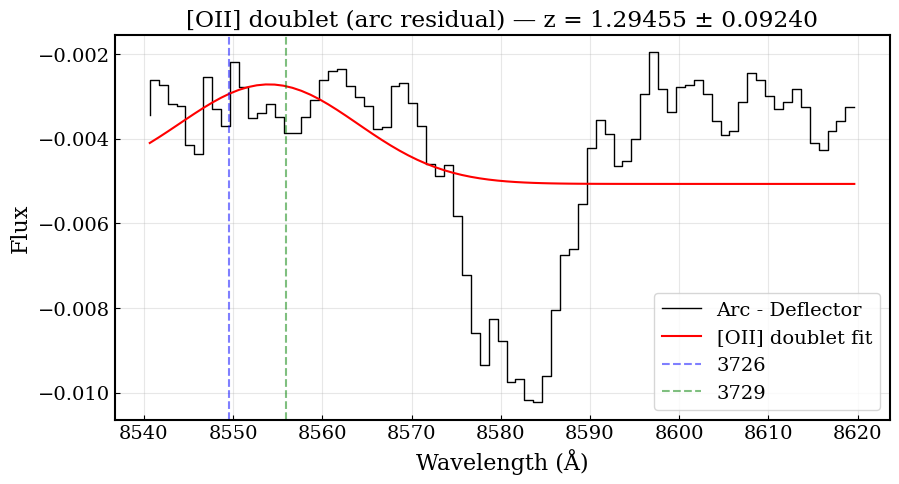


All emission lines in arc residual:
  [O II] 3726: z=1.29797 ± 0.00066
  [O II] 3729: z=1.30419 ± 0.00055
  [OII] doublet: z=1.29455 ± 0.09240
  Weighted z = 1.30164 ± 0.00042


In [9]:
# Extract arc spectrum from candidate arc spaxels
# ADJUST these indices based on the white-light image above
# These are indices into the FULL cube (not the 35:75, 30:70 subregion)
arc_y = slice(50, 65)  # adjust
arc_x = slice(56, 62)  # adjust — offset from deflector center

arc_flux = np.average(cube[:, arc_y, arc_x], axis=(1, 2))

# Subtract deflector continuum (rough)
arc_minus_defl = arc_flux - deflector_flux

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].step(lam_air, arc_flux, 'k', lw=0.8, label='Arc spaxels')
axes[0].step(lam_air, deflector_flux, 'r', lw=0.8, alpha=0.5, label='Deflector')
axes[0].set_ylabel('Flux')
axes[0].set_title('Arc vs deflector spectra')
axes[0].legend()

axes[1].step(lam_air, arc_minus_defl, 'b', lw=0.8, label='Arc - Deflector')
# Mark expected [OII] position
oii_obs = 3727.4 * (1 + z_src_guess)
axes[1].axvline(oii_obs, color='green', ls='--', alpha=0.7, label=f'[OII] at z={z_src_guess}')
axes[1].set_xlabel('Wavelength (Å)')
axes[1].set_ylabel('Flux')
axes[1].set_title('Residual (arc - deflector) — look for source emission')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- [OII] doublet fit on arc residual ---
oii_arc = fit_oii_doublet(lam_air, arc_minus_defl, z_guess=z_src_guess,
                           window_angstrom=40.0, noise=noise_flux)

if oii_arc['success']:
    print(f"[OII] doublet fit (arc - deflector):")
    print(f"  z = {oii_arc['z_fit']:.5f} ± {oii_arc['z_err']:.5f}")
    print(f"  3726 center: {oii_arc['center_3726']:.1f} Å")
    print(f"  3729 center: {oii_arc['center_3729']:.1f} Å")
    print(f"  Flux ratio (3726/3729): {oii_arc['ratio']:.2f}")
    print(f"  sigma: {oii_arc['sigma']:.2f} Å")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(oii_arc['wl_window'], oii_arc['flux_window'], 'k', lw=1, label='Arc - Deflector')
    ax.plot(oii_arc['wl_window'], oii_arc['model'], 'r', lw=1.5, label='[OII] doublet fit')
    ax.axvline(oii_arc['center_3726'], color='blue', ls='--', alpha=0.5, label='3726')
    ax.axvline(oii_arc['center_3729'], color='green', ls='--', alpha=0.5, label='3729')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux')
    ax.set_title(f"[OII] doublet (arc residual) — z = {oii_arc['z_fit']:.5f} ± {oii_arc['z_err']:.5f}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print(f"[OII] doublet fit failed on arc residual: {oii_arc.get('message', '')}")

# --- Also try all emission lines ---
src_arc_result = verify_redshift(
    lam_air, arc_minus_defl, z_guess=z_src_guess,
    noise=noise_flux, emission=True, window_angstrom=40.0
)

print(f"\nAll emission lines in arc residual:")
for name, r in src_arc_result['per_line'].items():
    status = f"z={r['z_fit']:.5f} ± {r['z_err']:.5f}" if r['success'] else 'FAILED'
    print(f"  {name}: {status}")
if src_arc_result['n_lines_fit'] > 0:
    print(f"  Weighted z = {src_arc_result['z_weighted']:.5f} ± {src_arc_result['z_weighted_err']:.5f}")

## 7. Blue KCWI cube — independent redshift check

The blue KCWI cube covers a different (bluer) wavelength range, giving access to
additional/different spectral features at the deflector and source redshifts.

In [10]:
# Load blue KCWI cube
blue_file = '../DESJ0206_medium_combined_blue.fits'
with fits.open(blue_file) as hdul:
    hdr_blue = hdul[0].header
    cube_blue = np.asarray(hdul[0].data, dtype=float)

# Build wavelength array — handle both CD3_3 and CDELT3 conventions
crval_b = hdr_blue['CRVAL3']
cdelt_b = hdr_blue.get('CD3_3', hdr_blue.get('CDELT3', None))
if cdelt_b is None:
    raise KeyError("Neither CD3_3 nor CDELT3 found in blue cube header")
npix_b = hdr_blue['NAXIS3']
crpix_b = hdr_blue.get('CRPIX3', 1.0)
pix_b = np.arange(npix_b)
lam_blue_vac = crval_b + cdelt_b * (pix_b + 1 - crpix_b)
lam_blue_air = vac_to_air(lam_blue_vac)

print(f"Blue cube shape: {cube_blue.shape}")
print(f"Wavelength keyword: {'CD3_3' if 'CD3_3' in hdr_blue else 'CDELT3'} = {cdelt_b}")
print(f"Blue wavelength range: {lam_blue_air[0]:.1f} - {lam_blue_air[-1]:.1f} Å (air)")
print(f"Red cube range:  {lam_air[0]:.1f} - {lam_air[-1]:.1f} Å (air)")

# At z=0.675, what rest-frame range does the blue cube cover?
z_defl = 0.675
print(f"\nBlue rest-frame range at z={z_defl}: {lam_blue_air[0]/(1+z_defl):.0f} - {lam_blue_air[-1]/(1+z_defl):.0f} Å")
print(f"Red rest-frame range at z={z_defl}:  {lam_air[0]/(1+z_defl):.0f} - {lam_air[-1]/(1+z_defl):.0f} Å")

Blue cube shape: (2595, 120, 120)
Wavelength keyword: CDELT3 = 1.0
Blue wavelength range: 3277.1 - 5870.4 Å (air)
Red cube range:  5623.4 - 8938.5 Å (air)

Blue rest-frame range at z=0.675: 1956 - 3505 Å
Red rest-frame range at z=0.675:  3357 - 5336 Å


=== Red cube (RL) ===
  Shape: (3317, 100, 100) (wav, y, x)
  CRVAL1 = 31.5561789
  CRVAL2 = -1.2385855
  CD1_1 = -8.3333333333333e-05
  CD2_2 = 8.33333333333333e-05
  CD1_2 = 0.0
  CD2_1 = 0.0
  CRPIX1 = 50.5
  CRPIX2 = 50.5
  IFUPA = 0.0

=== Blue cube (BM) ===
  Shape: (2595, 120, 120) (wav, y, x)
  CRVAL1 = 31.555908350566
  CRVAL2 = -1.2386944049737
  CRPIX1 = 62.74634739775
  CRPIX2 = 53.193218075984

Red deflector box:  x=[45:55], y=[45:64]
Blue deflector box: x=[55:65], y=[47:66]
  (offset: dx=10, dy=2 spaxels)


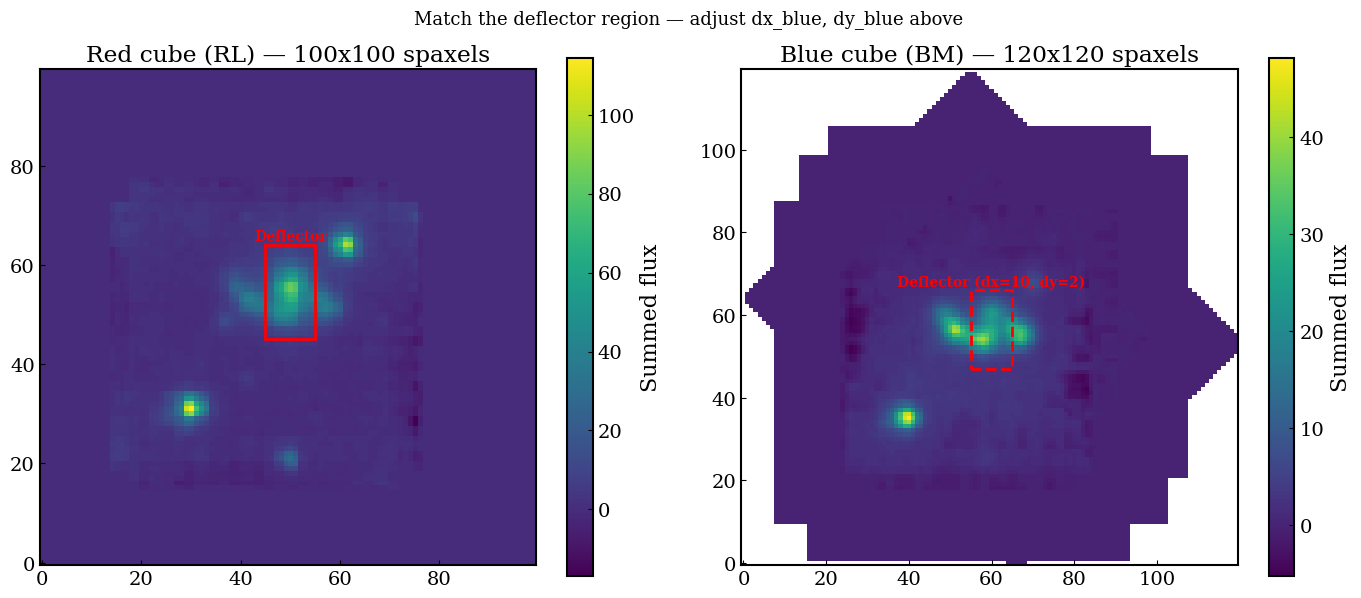


>>> Adjust dx_blue and dy_blue above until the red box on the blue
    image covers the same galaxy as the red cube. Re-run this cell. <<<


In [11]:
# Compare spatial orientation of blue vs red cubes
# Check WCS keywords, pixel scales, and PA to ensure same spaxel regions are valid
from astropy.wcs import WCS
from matplotlib.patches import Rectangle

print("=== Red cube (RL) ===")
print(f"  Shape: {cube.shape} (wav, y, x)")
for k in ['CRVAL1','CRVAL2','CD1_1','CD2_2','CD1_2','CD2_1','CRPIX1','CRPIX2','IFUPA','ROTPA']:
    if k in hdr:
        print(f"  {k} = {hdr[k]}")

print(f"\n=== Blue cube (BM) ===")
print(f"  Shape: {cube_blue.shape} (wav, y, x)")
for k in ['CRVAL1','CRVAL2','CD1_1','CD2_2','CD1_2','CD2_1','CRPIX1','CRPIX2','IFUPA','ROTPA']:
    if k in hdr_blue:
        print(f"  {k} = {hdr_blue[k]}")

# ---------------------------------------------------------------
# DEFLECTOR BOX PARAMETERS
# Red side (known good): x=45:55, y=45:64 (width=10, height=19)
# Blue side: START with the same, then ADJUST dx_blue, dy_blue
# to shift the box to match the deflector in the blue white-light
# ---------------------------------------------------------------
red_x0, red_y0, red_w, red_h = 45, 45, 10, 19  # red deflector box

dx_blue = 10   # <<< ADJUST: positive = shift box right in blue image
dy_blue = 2   # <<< ADJUST: positive = shift box up in blue image

blue_x0 = red_x0 + dx_blue
blue_y0 = red_y0 + dy_blue

print(f"\nRed deflector box:  x=[{red_x0}:{red_x0+red_w}], y=[{red_y0}:{red_y0+red_h}]")
print(f"Blue deflector box: x=[{blue_x0}:{blue_x0+red_w}], y=[{blue_y0}:{blue_y0+red_h}]")
print(f"  (offset: dx={dx_blue}, dy={dy_blue} spaxels)")

# White-light comparison with matched boxes
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wl_red = np.sum(cube, axis=0)
wl_blue = np.sum(cube_blue, axis=0)

# Red cube
im0 = axes[0].imshow(wl_red, origin='lower', cmap='viridis')
axes[0].set_title(f'Red cube (RL) — {cube.shape[2]}x{cube.shape[1]} spaxels')
axes[0].add_patch(Rectangle((red_x0, red_y0), red_w, red_h,
                              edgecolor='red', facecolor='none', lw=2, label='Deflector'))
axes[0].text(red_x0 + red_w/2, red_y0 + red_h + 1, 'Deflector',
             ha='center', color='red', fontsize=10, fontweight='bold')
plt.colorbar(im0, ax=axes[0], label='Summed flux')

# Blue cube — same box shape, shifted by (dx_blue, dy_blue)
im1 = axes[1].imshow(wl_blue, origin='lower', cmap='viridis')
axes[1].set_title(f'Blue cube (BM) — {cube_blue.shape[2]}x{cube_blue.shape[1]} spaxels')
axes[1].add_patch(Rectangle((blue_x0, blue_y0), red_w, red_h,
                              edgecolor='red', facecolor='none', lw=2, ls='--'))
axes[1].text(blue_x0 + red_w/2, blue_y0 + red_h + 1,
             f'Deflector (dx={dx_blue}, dy={dy_blue})',
             ha='center', color='red', fontsize=10, fontweight='bold')
plt.colorbar(im1, ax=axes[1], label='Summed flux')

plt.suptitle('Match the deflector region — adjust dx_blue, dy_blue above', fontsize=13)
plt.tight_layout()
plt.show()

print("\n>>> Adjust dx_blue and dy_blue above until the red box on the blue")
print("    image covers the same galaxy as the red cube. Re-run this cell. <<<")

Blue deflector: y=[47:66], x=[55:65]
Blue noise:     y=[30:42], x=[55:80]


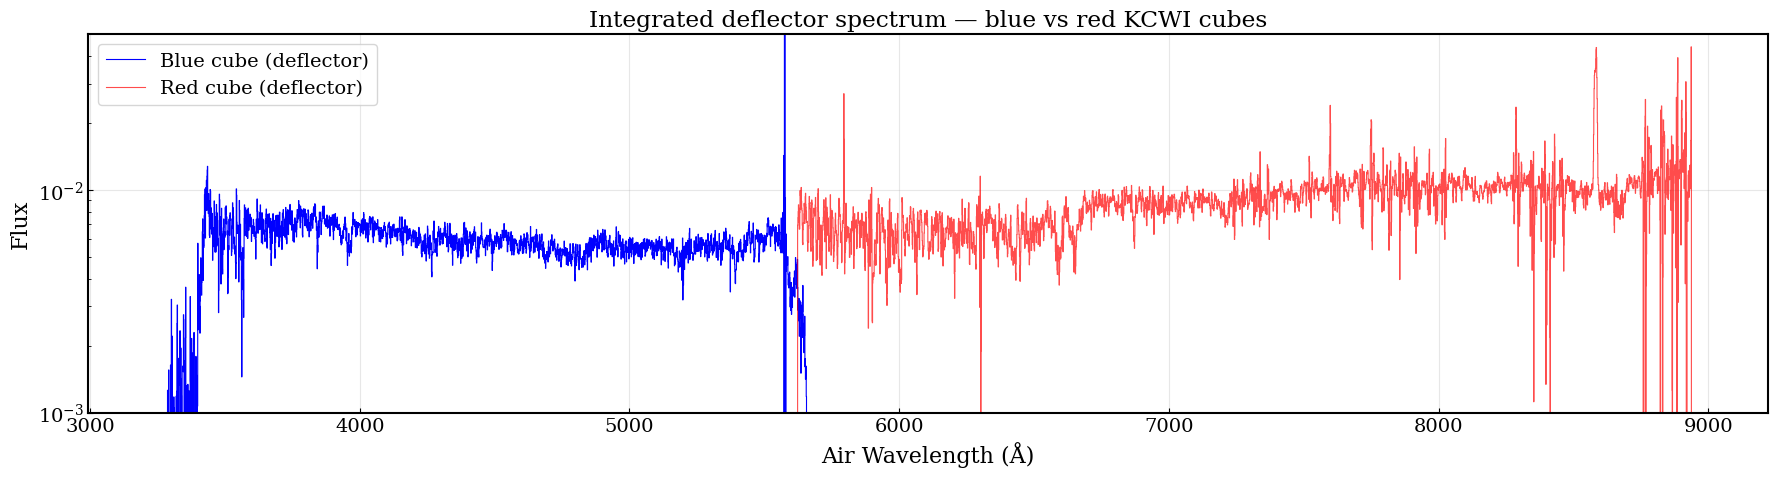

In [12]:
# Extract blue cube spectra using the offset-adjusted box from the cell above
# The deflector box is defined by blue_x0, blue_y0, red_w, red_h
defl_y_blue = slice(blue_y0, blue_y0 + red_h)
defl_x_blue = slice(blue_x0, blue_x0 + red_w)

# Noise region: shift by the same offset
noise_y0_red, noise_x0_red = 28, 45
noise_h_red, noise_w_red = 12, 25
noise_y_blue = slice(noise_y0_red + dy_blue, noise_y0_red + noise_h_red + dy_blue)
noise_x_blue = slice(noise_x0_red + dx_blue, noise_x0_red + noise_w_red + dx_blue)

print(f"Blue deflector: y=[{blue_y0}:{blue_y0+red_h}], x=[{blue_x0}:{blue_x0+red_w}]")
print(f"Blue noise:     y=[{noise_y0_red+dy_blue}:{noise_y0_red+noise_h_red+dy_blue}], "
      f"x=[{noise_x0_red+dx_blue}:{noise_x0_red+noise_w_red+dx_blue}]")

defl_blue = np.average(cube_blue[:, defl_y_blue, defl_x_blue], axis=(1, 2))
noise_blue = np.std(cube_blue[:, noise_y_blue, noise_x_blue], axis=(1, 2))

# Plot both cubes' spectra
fig, ax = plt.subplots(figsize=(18, 5))
ax.step(lam_blue_air, defl_blue, 'b', lw=0.8, label='Blue cube (deflector)')
ax.step(lam_air, deflector_flux, 'r', lw=0.8, alpha=0.7, label='Red cube (deflector)')
ax.set_xlabel('Air Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_title('Integrated deflector spectrum — blue vs red KCWI cubes')
ax.legend()
ax.grid(alpha=0.3)
ax.set_yscale('log')
ax.set_ylim(1e-3, 5e-2)
plt.tight_layout()
plt.show()

Blue cube range: 3277 - 5870 Å (air)
  → rest frame at z=0.675: 1956 - 3505 Å

Deflector ABSORPTION lines (z=0.675):
  Ca K            rest=3933.7  obs=6588.9 Å  ✗ outside
  Ca H            rest=3968.5  obs=6647.2 Å  ✗ outside
  H-delta         rest=4101.7  obs=6870.4 Å  ✗ outside
  G-band          rest=4304.4  obs=7209.9 Å  ✗ outside
  H-beta          rest=4861.3  obs=8142.7 Å  ✗ outside

Deflector EMISSION lines (z=0.675):
  [O II] 3726     rest=3726.0  obs=6241.1 Å  ✗ outside
  [O II] 3729     rest=3728.8  obs=6245.8 Å  ✗ outside
  H-beta em       rest=4861.3  obs=8142.7 Å  ✗ outside
  [O III] 4959    rest=4958.9  obs=8306.2 Å  ✗ outside
  [O III] 5007    rest=5006.8  obs=8386.5 Å  ✗ outside

Source EMISSION lines (z=1.302):
  [O II] 3726     rest=3726.0  obs=8577.3 Å  ✗ outside
  [O II] 3729     rest=3728.8  obs=8583.7 Å  ✗ outside
  H-beta          rest=4861.3  obs=11190.8 Å  ✗ outside
  [O III] 4959    rest=4958.9  obs=11415.4 Å  ✗ outside
  [O III] 5007    rest=5006.8  obs=11525

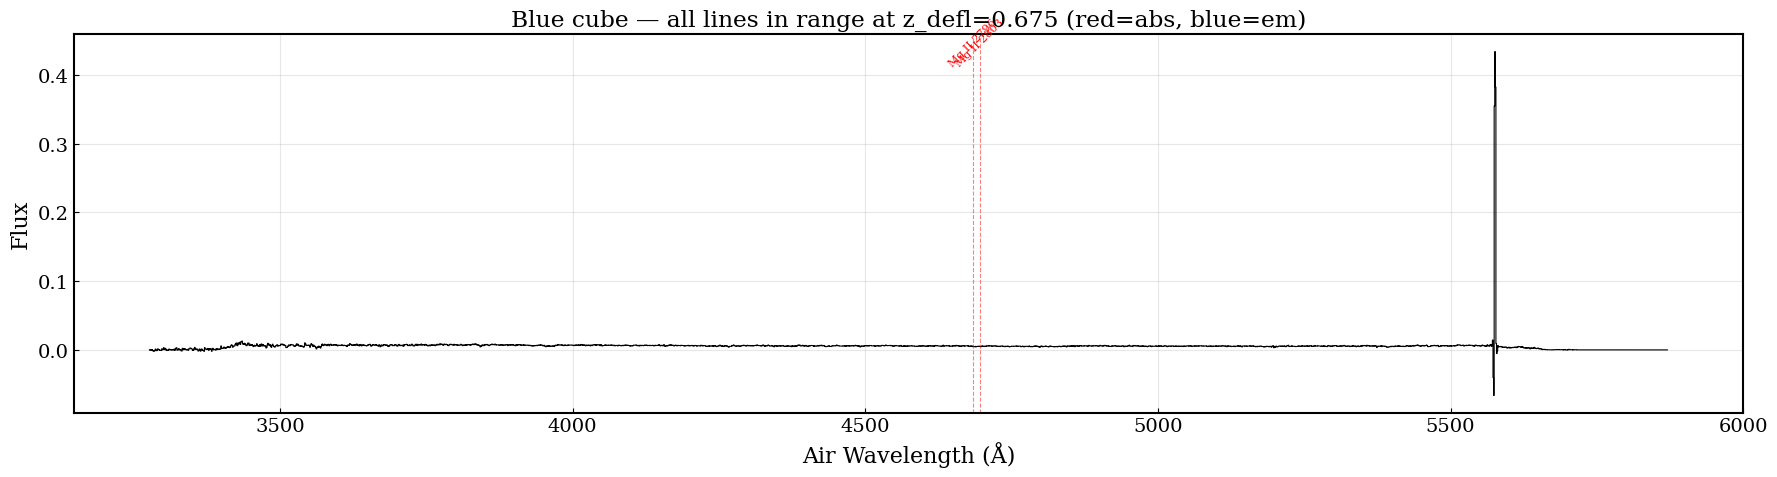

In [13]:
# Check which lines fall in the blue cube wavelength range
blue_lo, blue_hi = lam_blue_air[0], lam_blue_air[-1]

print(f"Blue cube range: {blue_lo:.0f} - {blue_hi:.0f} Å (air)")
print(f"  → rest frame at z={z_defl_guess}: {blue_lo/(1+z_defl_guess):.0f} - {blue_hi/(1+z_defl_guess):.0f} Å")

print(f"\nDeflector ABSORPTION lines (z={z_defl_guess}):")
for name, info in DEFLECTOR_ABS_LINES.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    in_range = "✓ IN RANGE" if blue_lo < obs < blue_hi else "✗ outside"
    print(f"  {name:<15} rest={info['lambda']:.1f}  obs={obs:.1f} Å  {in_range}")

print(f"\nDeflector EMISSION lines (z={z_defl_guess}):")
for name, info in DEFLECTOR_EM_LINES.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    in_range = "✓ IN RANGE" if blue_lo < obs < blue_hi else "✗ outside"
    print(f"  {name:<15} rest={info['lambda']:.1f}  obs={obs:.1f} Å  {in_range}")

print(f"\nSource EMISSION lines (z={z_src_guess}):")
for name, info in EMISSION_LINES.items():
    obs = info['lambda'] * (1 + z_src_guess)
    in_range = "✓ IN RANGE" if blue_lo < obs < blue_hi else "✗ outside"
    print(f"  {name:<15} rest={info['lambda']:.1f}  obs={obs:.1f} Å  {in_range}")

# Extended line list for bluer rest-frame features that may appear in the blue cube
# Only trusted features — excluded Fe II (blended, weak), Mg I 2853 (unreliable)
BLUE_EXTRA_ABS = {
    'Mg II 2796': {'lambda': 2796.35, 'label': 'Mg II 2796'},
    'Mg II 2803': {'lambda': 2803.53, 'label': 'Mg II 2803'},
    'Ca K':       {'lambda': 3933.66, 'label': 'Ca K'},
    'Ca H':       {'lambda': 3968.47, 'label': 'Ca H'},
    'H-delta':    {'lambda': 4101.74, 'label': r'H$\delta$'},
    'G-band':     {'lambda': 4304.40, 'label': 'G-band'},
}

BLUE_EXTRA_EM = {
    '[O II] 3726': {'lambda': 3726.03, 'label': '[O II] 3726'},
    '[O II] 3729': {'lambda': 3728.82, 'label': '[O II] 3729'},
    '[Ne III] 3869': {'lambda': 3868.76, 'label': '[Ne III]'},
    'H-epsilon':  {'lambda': 3970.07, 'label': r'H$\epsilon$'},
    'H-delta em': {'lambda': 4101.74, 'label': r'H$\delta$ em'},
    'H-gamma em': {'lambda': 4340.47, 'label': r'H$\gamma$ em'},
    'H-beta em':  {'lambda': 4861.33, 'label': r'H$\beta$ em'},
    '[O III] 5007': {'lambda': 5006.84, 'label': '[O III] 5007'},
}

print(f"\nExtended absorption lines at z={z_defl_guess} in blue range:")
blue_abs_in_range = {}
for name, info in BLUE_EXTRA_ABS.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    if blue_lo < obs < blue_hi:
        print(f"  ✓ {name:<15} rest={info['lambda']:.1f}  obs={obs:.1f} Å")
        blue_abs_in_range[name] = info

print(f"\nExtended emission lines at z={z_defl_guess} in blue range:")
blue_em_in_range = {}
for name, info in BLUE_EXTRA_EM.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    if blue_lo < obs < blue_hi:
        print(f"  ✓ {name:<15} rest={info['lambda']:.1f}  obs={obs:.1f} Å")
        blue_em_in_range[name] = info

# Plot spectrum with all in-range lines
fig, ax = plt.subplots(figsize=(18, 5))
ax.step(lam_blue_air, defl_blue, 'k', lw=0.8)
for name, info in blue_abs_in_range.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    ax.axvline(obs, color='red', ls='--', alpha=0.5, lw=0.8)
    ax.text(obs, ax.get_ylim()[1]*0.9, info['label'], fontsize=8, ha='center', color='red', rotation=45)
for name, info in blue_em_in_range.items():
    obs = info['lambda'] * (1 + z_defl_guess)
    ax.axvline(obs, color='blue', ls='--', alpha=0.5, lw=0.8)
    ax.text(obs, ax.get_ylim()[1]*0.85, info['label'], fontsize=8, ha='center', color='blue', rotation=45)
ax.set_xlabel('Air Wavelength (Å)')
ax.set_ylabel('Flux')
ax.set_title(f'Blue cube — all lines in range at z_defl={z_defl_guess} (red=abs, blue=em)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7b. Fit deflector absorption lines in blue cube

ABSORPTION LINES (blue cube, 2 lines attempted):
Line                      z_fit      z_err   center (Å)  sigma (Å)
-----------------------------------------------------------------
Mg II 2796              0.67779    0.00269      4691.69       9.54
Mg II 2803              0.67344    0.00281      4691.54       8.05
Weighted z (abs, blue) = 0.67571 ± 0.00194

EMISSION LINES (blue cube, 5 lines attempted):
Line                      z_fit      z_err   center (Å)  sigma (Å)
-----------------------------------------------------------------
No deflector emission lines detected in blue cube

--- Blue vs Red deflector comparison ---
  Red abs z  = 0.67564 ± 0.00033 (6 lines)
  Blue abs z = 0.67571 ± 0.00194 (2 lines)
  Delta z (B-R abs) = +0.00007
  Red em z   = 0.67496 ± 0.00013


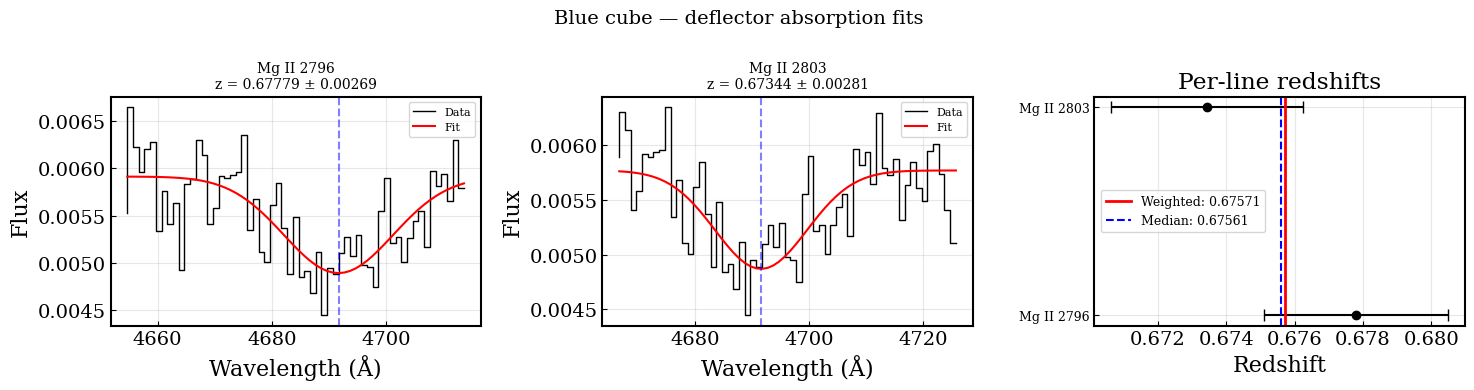

In [14]:
# Fit deflector absorption AND emission lines in the blue cube
# Uses the in-range line lists computed in the diagnostic cell above

# --- Absorption (use lines actually in the blue range) ---
abs_dict = blue_abs_in_range if blue_abs_in_range else DEFLECTOR_ABS_LINES
defl_blue_abs = verify_redshift(
    lam_blue_air, defl_blue, z_guess=z_defl_guess,
    noise=noise_blue, emission=False, window_angstrom=30.0,
    line_dict=abs_dict
)

print(f"ABSORPTION LINES (blue cube, {len(abs_dict)} lines attempted):")
print(f"{'Line':<20} {'z_fit':>10} {'z_err':>10} {'center (Å)':>12} {'sigma (Å)':>10}")
print('-' * 65)
for name, r in defl_blue_abs['per_line'].items():
    if r['success']:
        print(f"{name:<20} {r['z_fit']:10.5f} {r['z_err']:10.5f} "
              f"{r.get('center', np.nan):12.2f} {r.get('sigma', np.nan):10.2f}")
    else:
        print(f"{name:<20} {'FAILED':>10} {r.get('message', ''):>30}")
if defl_blue_abs['n_lines_fit'] > 0:
    print(f"Weighted z (abs, blue) = {defl_blue_abs['z_weighted']:.5f} ± {defl_blue_abs['z_weighted_err']:.5f}")
else:
    print("No absorption lines fit in blue cube")

# --- Emission (use lines actually in the blue range) ---
em_dict = blue_em_in_range if blue_em_in_range else DEFLECTOR_EM_LINES
defl_blue_em = verify_redshift(
    lam_blue_air, defl_blue, z_guess=z_defl_guess,
    noise=noise_blue, emission=True, window_angstrom=30.0,
    line_dict=em_dict
)

print(f"\nEMISSION LINES (blue cube, {len(em_dict)} lines attempted):")
print(f"{'Line':<20} {'z_fit':>10} {'z_err':>10} {'center (Å)':>12} {'sigma (Å)':>10}")
print('-' * 65)
for name, r in defl_blue_em['per_line'].items():
    if r['success']:
        print(f"{name:<20} {r['z_fit']:10.5f} {r['z_err']:10.5f} "
              f"{r.get('center', np.nan):12.2f} {r.get('sigma', np.nan):10.2f}")
    else:
        print(f"{name:<20} {'FAILED':>10} {r.get('message', ''):>30}")
if defl_blue_em['n_lines_fit'] > 0:
    print(f"Weighted z (em, blue) = {defl_blue_em['z_weighted']:.5f} ± {defl_blue_em['z_weighted_err']:.5f}")
else:
    print("No deflector emission lines detected in blue cube")

# Keep absorption result for downstream
defl_blue_result = defl_blue_abs

# --- Comparison ---
print(f"\n--- Blue vs Red deflector comparison ---")
print(f"  Red abs z  = {defl_abs_result['z_weighted']:.5f} ± {defl_abs_result['z_weighted_err']:.5f} ({defl_abs_result['n_lines_fit']} lines)")
if defl_blue_abs['n_lines_fit'] > 0:
    print(f"  Blue abs z = {defl_blue_abs['z_weighted']:.5f} ± {defl_blue_abs['z_weighted_err']:.5f} ({defl_blue_abs['n_lines_fit']} lines)")
    print(f"  Delta z (B-R abs) = {defl_blue_abs['z_weighted'] - defl_abs_result['z_weighted']:+.5f}")
if defl_em_result['n_lines_fit'] > 0:
    print(f"  Red em z   = {defl_em_result['z_weighted']:.5f} ± {defl_em_result['z_weighted_err']:.5f}")
if defl_blue_em['n_lines_fit'] > 0:
    print(f"  Blue em z  = {defl_blue_em['z_weighted']:.5f} ± {defl_blue_em['z_weighted_err']:.5f}")

# Plot fits
if defl_blue_abs['n_lines_fit'] > 0:
    fig = plot_line_fits(defl_blue_abs, title='Blue cube — deflector absorption fits')
    plt.show()
if defl_blue_em['n_lines_fit'] > 0:
    fig = plot_line_fits(defl_blue_em, title='Blue cube — deflector emission fits')
    plt.show()

### 7c. Source emission in blue cube

In [15]:
# Source emission lines in blue cube
# [OII] 3727 at z=1.302 → ~8580 Å — may or may not be in blue range
# Other lines at z=1.302: Ly-alpha 1216 → 2797 Å (UV, likely outside)
print(f"Blue range: {lam_blue_air[0]:.0f} - {lam_blue_air[-1]:.0f} Å")
print(f"[OII] at z=1.302: {3727.4*(1+1.302):.0f} Å")

# Try OII doublet fit
oii_blue = fit_oii_doublet(lam_blue_air, defl_blue, z_guess=z_src_guess,
                            window_angstrom=40.0, noise=noise_blue)

if oii_blue['success']:
    print(f"\n[OII] doublet fit (blue cube):")
    print(f"  z = {oii_blue['z_fit']:.5f} ± {oii_blue['z_err']:.5f}")
    print(f"  3726 center: {oii_blue['center_3726']:.1f} Å")
    print(f"  3729 center: {oii_blue['center_3729']:.1f} Å")
    print(f"  ratio: {oii_blue['ratio']:.2f}, sigma: {oii_blue['sigma']:.2f} Å")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.step(oii_blue['wl_window'], oii_blue['flux_window'], 'k', lw=1, label='Data')
    ax.plot(oii_blue['wl_window'], oii_blue['model'], 'r', lw=1.5, label='[OII] doublet fit')
    ax.axvline(oii_blue['center_3726'], color='blue', ls='--', alpha=0.5, label='3726')
    ax.axvline(oii_blue['center_3729'], color='green', ls='--', alpha=0.5, label='3729')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux')
    ax.set_title(f"[OII] doublet (blue cube) — z = {oii_blue['z_fit']:.5f} ± {oii_blue['z_err']:.5f}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print(f"[OII] not detected in blue cube: {oii_blue.get('message', '')}")

# Also try all emission lines
src_blue = verify_redshift(
    lam_blue_air, defl_blue, z_guess=z_src_guess,
    noise=noise_blue, emission=True, window_angstrom=30.0
)
print(f"\nAll emission lines in blue cube:")
for name, r in src_blue['per_line'].items():
    status = f"z={r['z_fit']:.5f} ± {r['z_err']:.5f}" if r['success'] else 'FAILED'
    print(f"  {name}: {status}")

Blue range: 3277 - 5870 Å
[OII] at z=1.302: 8580 Å
[OII] not detected in blue cube: Too few pixels in window

All emission lines in blue cube:


## 8. Bootstrap redshift errors

Perturb the spectrum N times using noise-scaled Rademacher wild bootstrap,
re-fit all lines each time, and collect the distribution of weighted-average z.

In [16]:
# Reload to pick up bootstrap_redshift
importlib.reload(rv)
from scripts.redshift_verify import bootstrap_redshift

N_BOOT = 500

# --- Deflector absorption (red cube) ---
print("Bootstrapping deflector absorption redshift (red cube)...")
boot_defl_abs = bootstrap_redshift(
    lam_air, deflector_flux, noise_flux, z_guess=z_defl_guess,
    line_dict=DEFLECTOR_ABS_LINES, emission=False,
    window_angstrom=30.0, n_bootstrap=N_BOOT, seed=42
)
print(f"  z = {boot_defl_abs['z_p50']:.5f} -{boot_defl_abs['z_err_lo']:.5f} +{boot_defl_abs['z_err_hi']:.5f}")
print(f"  Failed: {boot_defl_abs['n_failed']}/{N_BOOT}")

# --- Deflector emission (red cube) ---
print("\nBootstrapping deflector emission redshift (red cube)...")
boot_defl_em = bootstrap_redshift(
    lam_air, deflector_flux, noise_flux, z_guess=z_defl_guess,
    line_dict=DEFLECTOR_EM_LINES, emission=True,
    window_angstrom=30.0, n_bootstrap=N_BOOT, seed=42
)
if boot_defl_em['n_failed'] < N_BOOT:
    print(f"  z = {boot_defl_em['z_p50']:.5f} -{boot_defl_em['z_err_lo']:.5f} +{boot_defl_em['z_err_hi']:.5f}")
    print(f"  Failed: {boot_defl_em['n_failed']}/{N_BOOT}")
else:
    print("  All iterations failed — no emission lines detected")

# --- Source [OII] (red cube, arc residual if available) ---
try:
    print("\nBootstrapping source redshift (arc residual)...")
    boot_src = bootstrap_redshift(
        lam_air, arc_minus_defl, noise_flux, z_guess=z_src_guess,
        line_dict=EMISSION_LINES, emission=True,
        window_angstrom=40.0, n_bootstrap=N_BOOT, seed=42
    )
    if boot_src['n_failed'] < N_BOOT:
        print(f"  z = {boot_src['z_p50']:.5f} -{boot_src['z_err_lo']:.5f} +{boot_src['z_err_hi']:.5f}")
        print(f"  Failed: {boot_src['n_failed']}/{N_BOOT}")
    else:
        print("  All iterations failed — no source emission detected")
except NameError:
    print("\nSkipping source bootstrap — arc_minus_defl not available (run section 6 first)")
    boot_src = None

Bootstrapping deflector absorption redshift (red cube)...
  z = 0.67535 -0.00039 +0.00046
  Failed: 0/500

Bootstrapping deflector emission redshift (red cube)...
  z = 0.67527 -0.00048 +0.00031
  Failed: 0/500

Bootstrapping source redshift (arc residual)...
  z = 1.30120 -0.00194 +0.00242
  Failed: 0/500


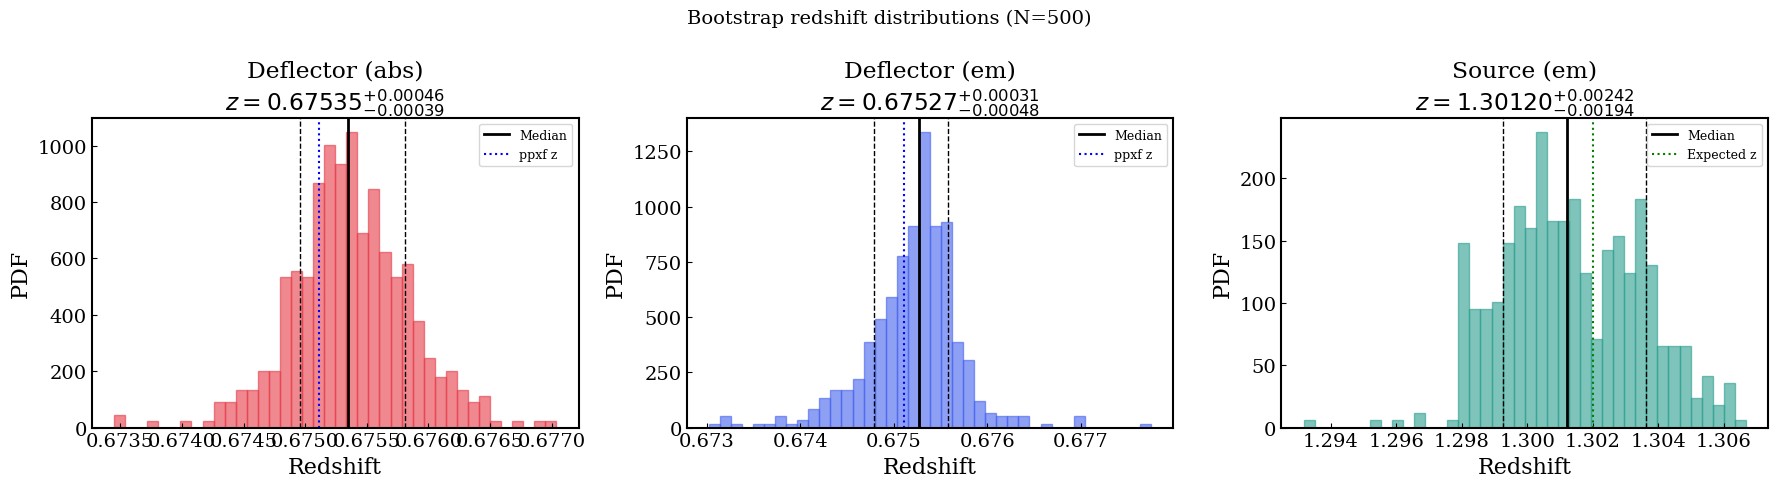

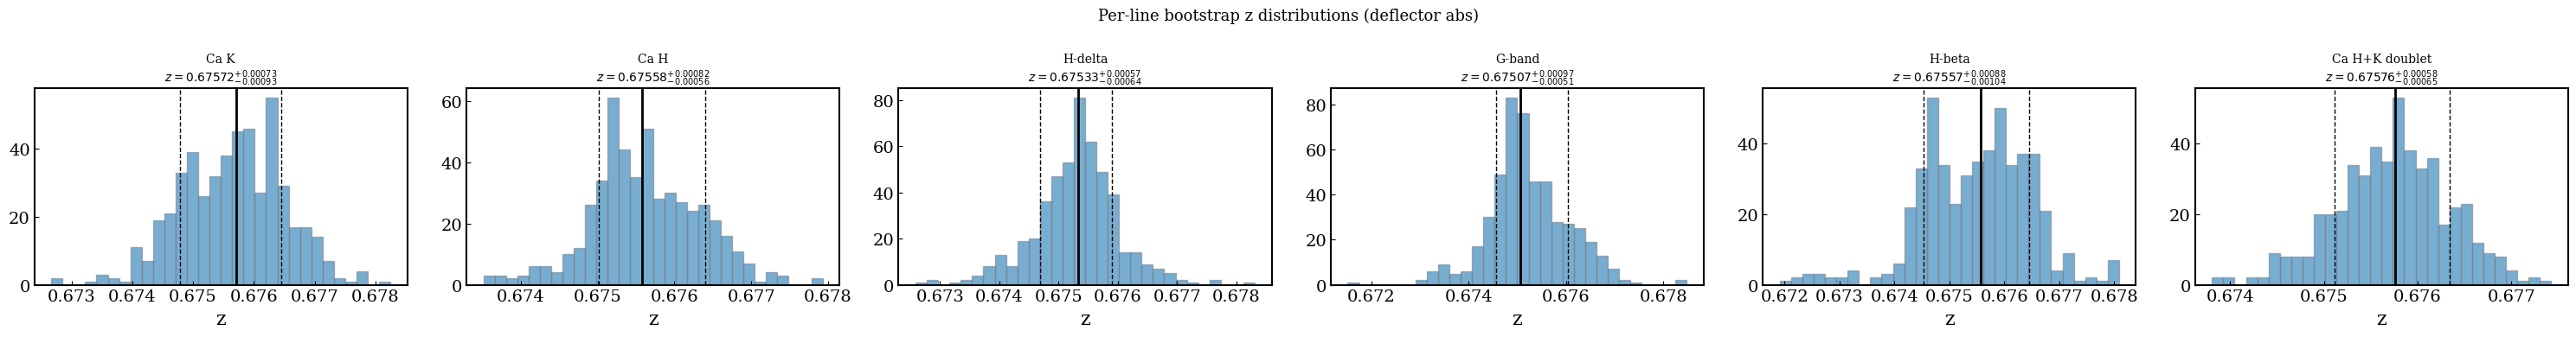

: 

In [ ]:
# Plot bootstrap distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Deflector absorption
ax = axes[0]
valid = boot_defl_abs['z_samples'][np.isfinite(boot_defl_abs['z_samples'])]
ax.hist(valid, bins=40, color='#e63946', alpha=0.6, edgecolor='#e63946', density=True)
ax.axvline(boot_defl_abs['z_p50'], color='k', ls='-', lw=2, label='Median')
ax.axvline(boot_defl_abs['z_p16'], color='k', ls='--', lw=1)
ax.axvline(boot_defl_abs['z_p84'], color='k', ls='--', lw=1)
ax.axvline(0.67511, color='blue', ls=':', lw=1.5, label='ppxf z')
ax.set_xlabel('Redshift')
ax.set_ylabel('PDF')
ax.set_title(f"Deflector (abs)\n$z = {boot_defl_abs['z_p50']:.5f}"
             f"_{{-{boot_defl_abs['z_err_lo']:.5f}}}^{{+{boot_defl_abs['z_err_hi']:.5f}}}$")
ax.legend(fontsize=9)

# Deflector emission
ax = axes[1]
valid_em = boot_defl_em['z_samples'][np.isfinite(boot_defl_em['z_samples'])]
if len(valid_em) > 10:
    ax.hist(valid_em, bins=40, color='#4361ee', alpha=0.6, edgecolor='#4361ee', density=True)
    ax.axvline(boot_defl_em['z_p50'], color='k', ls='-', lw=2, label='Median')
    ax.axvline(boot_defl_em['z_p16'], color='k', ls='--', lw=1)
    ax.axvline(boot_defl_em['z_p84'], color='k', ls='--', lw=1)
    ax.axvline(0.67511, color='blue', ls=':', lw=1.5, label='ppxf z')
    ax.set_title(f"Deflector (em)\n$z = {boot_defl_em['z_p50']:.5f}"
                 f"_{{-{boot_defl_em['z_err_lo']:.5f}}}^{{+{boot_defl_em['z_err_hi']:.5f}}}$")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, 'No deflector\nemission detected', transform=ax.transAxes,
            ha='center', va='center', fontsize=14)
    ax.set_title('Deflector (em)')
ax.set_xlabel('Redshift')
ax.set_ylabel('PDF')

# Source
ax = axes[2]
if boot_src is not None:
    valid_src = boot_src['z_samples'][np.isfinite(boot_src['z_samples'])]
    if len(valid_src) > 10:
        ax.hist(valid_src, bins=40, color='#2a9d8f', alpha=0.6, edgecolor='#2a9d8f', density=True)
        ax.axvline(boot_src['z_p50'], color='k', ls='-', lw=2, label='Median')
        ax.axvline(boot_src['z_p16'], color='k', ls='--', lw=1)
        ax.axvline(boot_src['z_p84'], color='k', ls='--', lw=1)
        ax.axvline(1.302, color='green', ls=':', lw=1.5, label='Expected z')
        ax.set_title(f"Source (em)\n$z = {boot_src['z_p50']:.5f}"
                     f"_{{-{boot_src['z_err_lo']:.5f}}}^{{+{boot_src['z_err_hi']:.5f}}}$")
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, 'No source\nemission detected', transform=ax.transAxes,
                ha='center', va='center', fontsize=14)
        ax.set_title('Source (em)')
else:
    ax.text(0.5, 0.5, 'Source bootstrap\nnot run', transform=ax.transAxes,
            ha='center', va='center', fontsize=14)
    ax.set_title('Source (em)')
ax.set_xlabel('Redshift')
ax.set_ylabel('PDF')

plt.suptitle(f'Bootstrap redshift distributions (N={N_BOOT})', fontsize=14)
plt.tight_layout()
plt.show()

# Per-line distributions for deflector absorption
per_line = boot_defl_abs['per_line_samples']
n_lines = len(per_line)
if n_lines > 0:
    fig, axes = plt.subplots(1, n_lines, figsize=(5*n_lines, 4))
    if n_lines == 1:
        axes = [axes]
    for ax, (name, samples) in zip(axes, per_line.items()):
        valid = samples[np.isfinite(samples)]
        if len(valid) > 5:
            ax.hist(valid, bins=30, alpha=0.6, edgecolor='gray')
            p16, p50, p84 = np.percentile(valid, [16, 50, 84])
            ax.axvline(p50, color='k', ls='-', lw=2)
            ax.axvline(p16, color='k', ls='--', lw=1)
            ax.axvline(p84, color='k', ls='--', lw=1)
            ax.set_title(f"{name}\n$z = {p50:.5f}_{{-{p50-p16:.5f}}}^{{+{p84-p50:.5f}}}$", fontsize=10)
        else:
            ax.set_title(f"{name}\n(too few fits)")
        ax.set_xlabel('z')
    plt.suptitle('Per-line bootstrap z distributions (deflector abs)', fontsize=13)
    plt.tight_layout()
    plt.show()

## 9. Summary

In [18]:
print('=' * 70)
print('REDSHIFT VERIFICATION SUMMARY — AGEL0206')
print('=' * 70)

# --- Deflector ---
print(f"\nDeflector (absorption lines):")
print(f"  {'Source':<25} {'z':>10} {'err_lo':>8} {'err_hi':>8} {'N':>4}")
print(f"  {'-'*55}")

# Single-fit results
print(f"  {'Red cube (Gaussian)':<25} {defl_result['z_weighted']:10.5f} {defl_result['z_weighted_err']:8.5f} {'':>8} {defl_result['n_lines_fit']:4d}")
try:
    print(f"  {'Blue cube (Gaussian)':<25} {defl_blue_result['z_weighted']:10.5f} {defl_blue_result['z_weighted_err']:8.5f} {'':>8} {defl_blue_result['n_lines_fit']:4d}")
except NameError:
    pass

# Bootstrap results
print(f"  {'Red abs (bootstrap)':<25} {boot_defl_abs['z_p50']:10.5f} {boot_defl_abs['z_err_lo']:8.5f} {boot_defl_abs['z_err_hi']:8.5f}")
try:
    valid_em = boot_defl_em['z_samples'][np.isfinite(boot_defl_em['z_samples'])]
    if len(valid_em) > 10:
        print(f"  {'Red em (bootstrap)':<25} {boot_defl_em['z_p50']:10.5f} {boot_defl_em['z_err_lo']:8.5f} {boot_defl_em['z_err_hi']:8.5f}")
except NameError:
    pass

if cahk['success']:
    print(f"\n  Ca H+K doublet (red):  z = {cahk['z_fit']:.5f} ± {cahk['z_err']:.5f}")

print(f"\n  ppxf z (input) = 0.67511")

# --- Source ---
print(f"\nSource (emission lines):")
try:
    if oii_int['success']:
        print(f"  {'Red [OII] doublet':<25} z = {oii_int['z_fit']:.5f} ± {oii_int['z_err']:.5f}")
except NameError:
    pass
try:
    if oii_arc['success']:
        print(f"  {'Red arc [OII]':<25} z = {oii_arc['z_fit']:.5f} ± {oii_arc['z_err']:.5f}")
except NameError:
    pass
try:
    if oii_blue['success']:
        print(f"  {'Blue [OII] doublet':<25} z = {oii_blue['z_fit']:.5f} ± {oii_blue['z_err']:.5f}")
except NameError:
    pass
try:
    if boot_src is not None:
        valid_src = boot_src['z_samples'][np.isfinite(boot_src['z_samples'])]
        if len(valid_src) > 10:
            print(f"  {'Source (bootstrap)':<25} {boot_src['z_p50']:10.5f} {boot_src['z_err_lo']:8.5f} {boot_src['z_err_hi']:8.5f}")
except NameError:
    pass

print(f"\n  Expected source z = 1.302")
print('=' * 70)

REDSHIFT VERIFICATION SUMMARY — AGEL0206

Deflector (absorption lines):
  Source                             z   err_lo   err_hi    N
  -------------------------------------------------------
  Red cube (Gaussian)          0.67564  0.00033             6
  Blue cube (Gaussian)         0.67571  0.00194             2
  Red abs (bootstrap)          0.67535  0.00039  0.00046
  Red em (bootstrap)           0.67527  0.00048  0.00031

  Ca H+K doublet (red):  z = 0.67567 ± 0.00069

  ppxf z (input) = 0.67511

Source (emission lines):
  Red [OII] doublet         z = 1.30251 ± 0.00004
  Red arc [OII]             z = 1.29455 ± 0.09240
  Source (bootstrap)           1.30120  0.00194  0.00242

  Expected source z = 1.302
